## Analysing the fitted parameters of the Transfer Function (FS neurons).

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [3]:
from utils.Plots_helper import *
from ntmf.transfer_function import *
from ntmf.config import get_params_model_SI, get_network_config, adding_K_params


In [4]:
import os
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 

In [5]:
from sklearn.decomposition import PCA

In [6]:
neuron_model = 'FS'
fig_name = 'Analysing_TF_fitted_params_FS'

In [7]:
# Load
#with open("results_FS_top_10.json", "r") as f:
with open("full_range/alpha_results_TF_FS_v1_best_10.json", "r") as f:
    data = json.load(f)

# Extract into arrays
alphas = np.array([d["alpha"] for d in data])
errors = np.array([d["mean_error"] for d in data])
poly_params = np.array([d["polynomial_params"] for d in data])  # shape: (n_models, 10)

n_models, n_params = poly_params.shape
print(poly_params.shape)

(10, 10)


### Summary of best 10 parameter sets

In [8]:
params_name = ['P_0', 'P_mu', 'P_sig', 'P_tau', 'P_mu2', 'P_sig2', 'P_tau2', 'P_mu_sig', 'P_mu_tau', 'P_sig_tau']

In [9]:
means = poly_params.mean(axis=0)
stds  = poly_params.std(axis=0)

df_stats = pd.DataFrame({
    "param_id": np.arange(n_params),
    "params_name": params_name,
    "mean": means,
    "std": stds
})

print(df_stats)

   param_id params_name      mean       std
0         0         P_0 -0.049187  0.000273
1         1        P_mu -0.000930  0.000867
2         2       P_sig  0.019814  0.010005
3         3       P_tau  0.007670  0.004712
4         4       P_mu2  0.001470  0.000176
5         5      P_sig2  0.005840  0.011434
6         6      P_tau2  0.047615  0.023713
7         7    P_mu_sig  0.001262  0.000742
8         8    P_mu_tau -0.009937  0.001289
9         9   P_sig_tau  0.059410  0.023259


In [10]:
### Computing Z-score
poly_z = (poly_params - means) / stds

## Plots

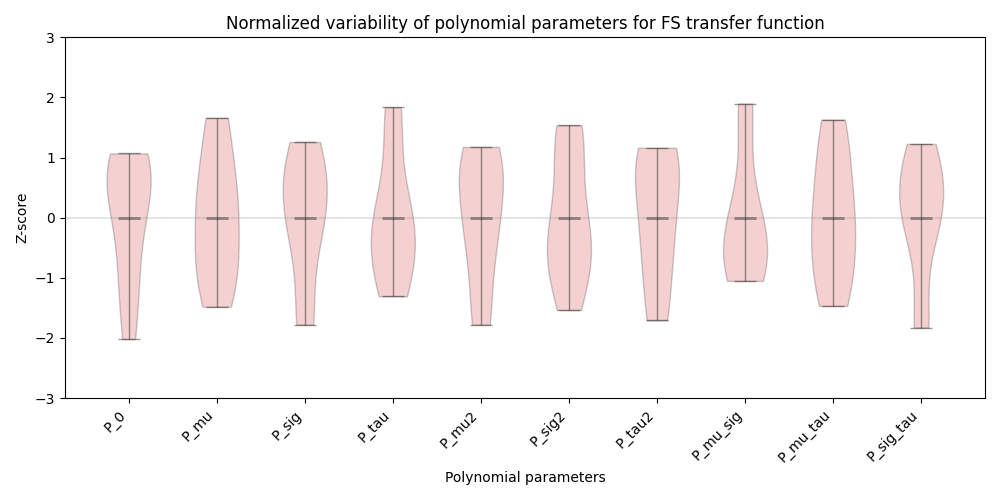

In [11]:
# Violin plot
fig = plot_violin(neuron_model, poly_z, params_name)
figs.append(fig)

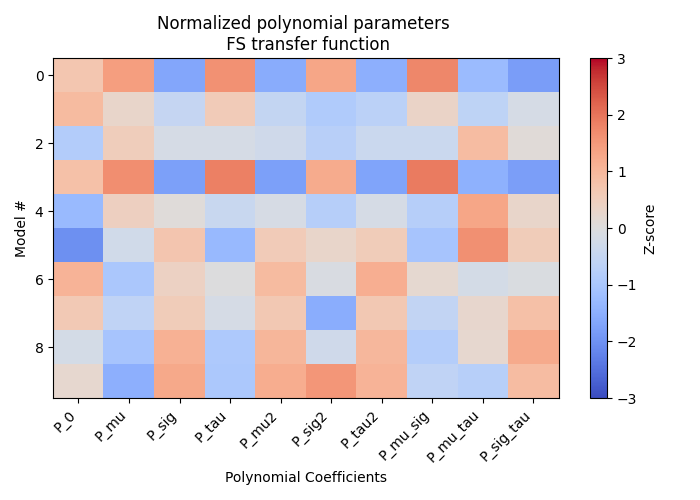

In [12]:
# Heatmap plot
fig = plot_poly_zscore_heatmap(neuron_model, poly_z, params_name)
figs.append(fig)

In [13]:
# Computing correlation with error
corrs = [np.corrcoef(poly_z[:, i], errors)[0,1] for i in range(n_params)]

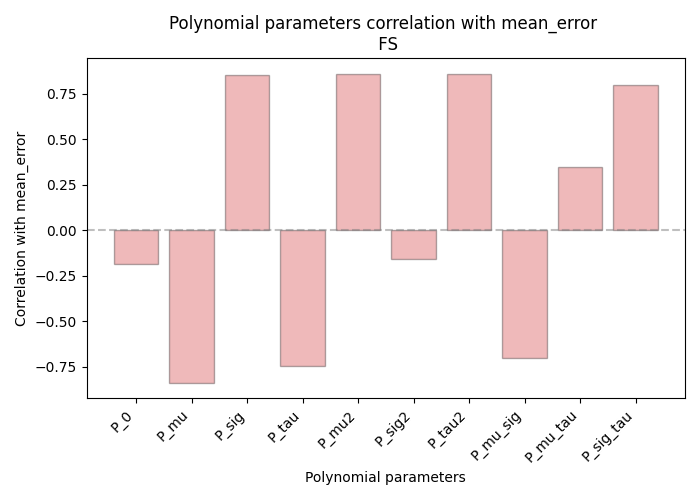

In [14]:
# Correlation between the coefficients and the error
fig = plot_poly_correlation_error(neuron_model, corrs, params_name)
figs.append(fig)

#Positive correlation --> larger parameter values --> larger errors
#Negative correlation --> larger parameter values --> smaller errors
#Correlation close to zero --> no linear relationship with error

In [15]:
# Computing correlation of the parameters between each others
corr_matrix = np.corrcoef(poly_z.T)

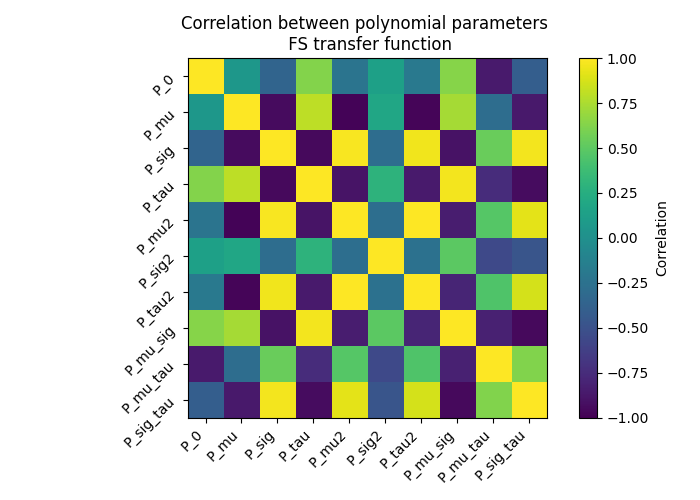

In [16]:
# Correlation between the coefficients
fig = plot_corr_matrix(neuron_model, corr_matrix, params_name)
figs.append(fig)

In [17]:
print(f'{params_name[2]},{params_name[4]}, and {params_name[6]} show strong positive correlations with each other.') 
print(f'{params_name[1]},{params_name[3]}, and {params_name[7]} show similar patterns of negative correlations.') 

P_sig,P_mu2, and P_tau2 show strong positive correlations with each other.
P_mu,P_tau, and P_mu_sig show similar patterns of negative correlations.


In [18]:
### PCA ###
pca = PCA()
X_pca = pca.fit_transform(poly_params)
expl_var = pca.explained_variance_ratio_
cum_var  = np.cumsum(expl_var)

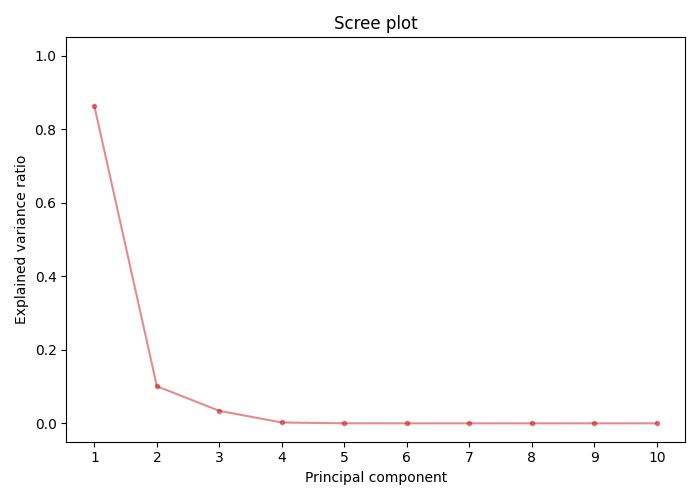

In [19]:
fig = plot_scree(neuron_model, expl_var)
figs.append(fig)

In [20]:
cum_var, expl_var

(array([0.86276834, 0.9636973 , 0.99761465, 0.99992017, 0.99999242,
        0.99999978, 0.99999998, 1.        , 1.        , 1.        ]),
 array([8.62768342e-01, 1.00928960e-01, 3.39173494e-02, 2.30551766e-03,
        7.22543635e-05, 7.35674336e-06, 1.98486485e-07, 2.07435929e-08,
        6.53557920e-10, 1.36618698e-35]))

In [21]:
print(f'PC1 and PC2 explains {((expl_var[0]+expl_var[1]) * 100):.2f}% of the variance!')

PC1 and PC2 explains 96.37% of the variance!


In [22]:
loadings_values = pd.DataFrame(
    pca.components_[:2],   # only PC1 and PC2
    columns=params_name,
    index=['PC1', 'PC2']
)

print(loadings_values)

          P_0      P_mu     P_sig     P_tau     P_mu2    P_sig2    P_tau2  \
PC1  0.002540  0.023754 -0.289038  0.127454 -0.005042  0.135412 -0.666470   
PC2  0.003661 -0.018953  0.090206 -0.007392  0.002524  0.843841  0.431316   

     P_mu_sig  P_mu_tau  P_sig_tau  
PC1  0.019722 -0.021447  -0.660491  
PC2  0.013719 -0.044281  -0.301959  


In [23]:
for pc in ['PC1', 'PC2']:
    print(f"\nTop contributors to {pc}")
    print(loadings_values.loc[pc].abs().sort_values(ascending=False))


Top contributors to PC1
P_tau2       0.666470
P_sig_tau    0.660491
P_sig        0.289038
P_sig2       0.135412
P_tau        0.127454
P_mu         0.023754
P_mu_tau     0.021447
P_mu_sig     0.019722
P_mu2        0.005042
P_0          0.002540
Name: PC1, dtype: float64

Top contributors to PC2
P_sig2       0.843841
P_tau2       0.431316
P_sig_tau    0.301959
P_sig        0.090206
P_mu_tau     0.044281
P_mu         0.018953
P_mu_sig     0.013719
P_tau        0.007392
P_0          0.003661
P_mu2        0.002524
Name: PC2, dtype: float64


### Interpretation?

PC1 --> How strongly fluctuations interact with the synaptic timescale?

PC2 --> How variance and time constant jointly shape gain?

mu terms are the least relevant

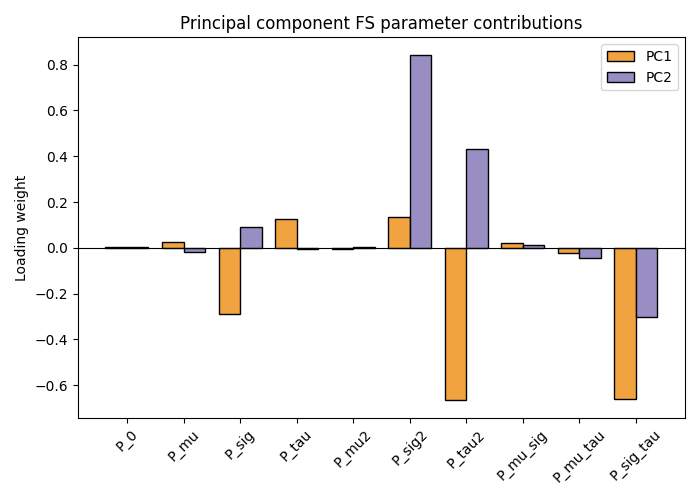

In [24]:
pc1 = loadings_values.loc['PC1']
pc2 = loadings_values.loc['PC2']

fig = plot_pca_parameter_contributions(neuron_model, pc1, pc2)
figs.append(fig)

In [25]:
# PCA biplot
loadings = pca.components_

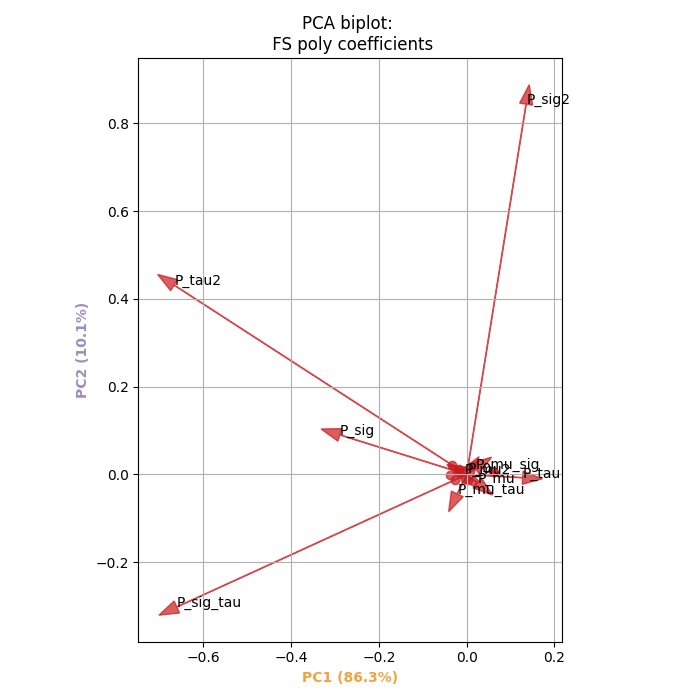

In [26]:
fig = plot_pca_biplot(neuron_model, params_name, X_pca, loadings, expl_var)
figs.append(fig)

As we saw, PC1 and PC2 explain 98.5% of the variance; therefore, parameter loadings projected onto this plane capture nearly all parameter variability. Arrow length reflects the strength of each parameter’s contribution to the dominant PCA modes.

## Testing distribution mean error as a function of alphas.

In [27]:
data_folder = '../../neuron_models/AdEx'
idx = 0 # in this case only one model per cell type is provided

params_SI = get_params_model_SI(neuron_model = neuron_model,
                             json_file_name = os.path.join(data_folder, neuron_model + '.json'))

In [28]:
network_config_folder = '../../config/'
network_file_name = 'network_config_file_v0.json'

network_config = get_network_config(json_file_name =  os.path.join(network_config_folder, network_file_name))

params_SI = adding_K_params(neuron_params = params_SI,
                            network_config = network_config)

In [29]:
simulation_folder = '../data_extraction/simulations/TF_FS_v1'
# --- Load the data ---
df_FS = pd.read_csv(
    os.path.join(simulation_folder, 'testing_TF_data_FS.dat'),
    sep=r'\s+',
    header = 0
)
x_s = sorted(df_FS['input_exc'].unique())
y_s = sorted(df_FS['input_inh'].unique())
df_FS_slice_array_std = df_FS['std_f_out'].to_numpy().reshape(len(y_s), len(x_s))

Mask = True

# min and max freq of the excitatory and inhibitory external input
min_freq = 0
max_freq = 20
if Mask == True:
    # Define range
    x_s = np.array(x_s)
    y_s = np.array(y_s)
    
  
    x_mask = (x_s >= min_freq) & (x_s <= max_freq)
    y_mask = (x_s >= min_freq) & (x_s <= max_freq)
    
    x_s_sel = x_s[x_mask]
    y_s_sel = y_s[y_mask]
    
    # Filter dataframe
    df_sel = df_FS[
        (df_FS['input_exc'] >= min_freq) & (df_FS['input_exc'] <= max_freq) &
        (df_FS['input_inh'] >= min_freq) & (df_FS['input_inh'] <= max_freq)
    ]
    
    # Pivot to 2D grid
    df_FS_slice_array_masked = (
        df_sel
        .pivot(index='input_inh', columns='input_exc', values='avg_f_out')
        .loc[y_s_sel, x_s_sel]
        .to_numpy()
    )

    df_FS_slice_array_std_masked = (
        df_sel
        .pivot(index='input_inh', columns='input_exc', values='std_f_out')
        .loc[y_s_sel, x_s_sel]
        .to_numpy()
    )
    inh_vals = y_s_sel
    df_FS = df_sel
    df_FS_slice_array_std = df_FS_slice_array_std_masked

In [30]:
for alpha_idx in range(0, len(alphas)):
    df_FS[f'fit_rate_alpha_{alpha_idx}'] = TF_template(
    data=df_FS, params=params_SI,
    poly_params=poly_params[alpha_idx], alpha=alphas[alpha_idx]
    )
    
unique_inh = np.sort(df_FS['input_inh'].unique())
colors = cm.viridis(np.linspace(0, 1, len(unique_inh)))

In [31]:
#df_FS

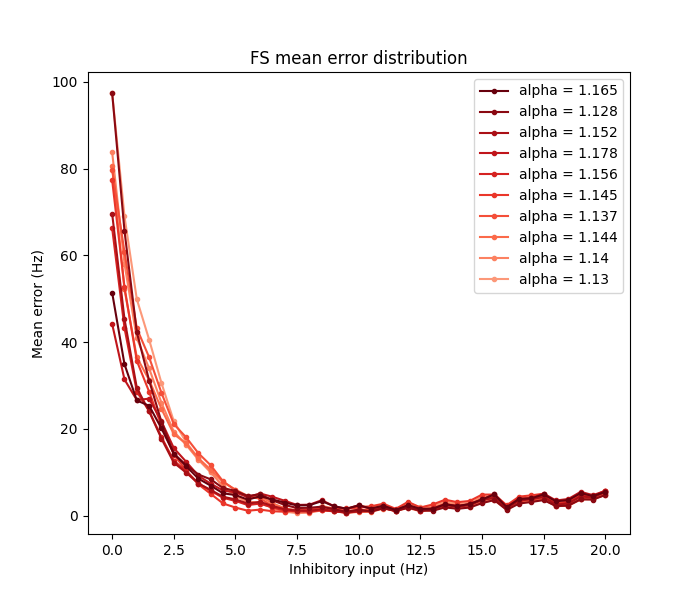

In [32]:
fig = plt.figure(figsize=(7,6))
for alpha_idx in reversed(range(0, len(alphas))):
    distr_mean_error = get_mean_error_distribution(neuron_model, df_FS,
                                                   poly_params[alpha_idx], params_SI,
                                                   alphas[alpha_idx],
                                                   unique_inh,
                                                   alpha_idx = alpha_idx)
    
    fig = plots_TF_distr_mean_error(neuron_model, inh_vals, distr_mean_error,
                                    alpha = alphas[alpha_idx], alpha_idx = alpha_idx, fig = fig)
figs.append(fig)

In [33]:
save_figs(fig_path, fig_name, figs)